In [1]:
import pandas as pd
from pathlib import Path

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [2]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [3]:
def basicColHist(df, var:str, title:str|None = None, xLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.hist(df[var], bins = 50)

    if title == None: 
        title = f'{var} of BH-Sol systems at inital detached state'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = var 
    ax.set_xlabel(xLabel)
    ax.set_ylabel('count')

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 

In [4]:
pop = Population(str(DataPath / 'bhSol_10Gyr_LowPorb_Subpop.h5'))

In [5]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oRLO1_CC1_END': 129,
         'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 101,
         'ZAMS_oCE1_CC1_END': 77,
         'ZAMS_oRLO1-contact_CC1_END': 32,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_maxtime_END': 28,
         'ZAMS_oCE1_CC1_oRLO2_CC2_END': 27,
         'ZAMS_oCE1_CC1_oRLO2_oCE2_oMerging2_END': 25,
         'ZAMS_oRLO1_CC1_oRLO2_oCE2_oMerging2_END': 24,
         'ZAMS_oCE1_CC1_CC2_maxtime_END': 3,
         'ZAMS_oCE1_CC1_oRLO2_CC2_FAILED': 3,
         'ZAMS_oRLO1-contact_CC1_oRLO2_CC2_maxtime_END': 2,
         'ZAMS_oRLO1-reverse_CC1_END': 2,
         'ZAMS_oRLO1-contact_CC1_oRLO2_oCE2_oMerging2_END': 1,
         'ZAMS_oRLO1-reverse_CC1_oRLO2_oCE2_oMerging2_END': 1})

In [6]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [7]:
bhSolRows = pd.read_csv(DataPath / 'threeDayPorb_solBHPairRows.csv')

In [8]:
bhSolRows[bhSolRows['S2_mass'] < 2.3][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
29,3.691715e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.747350,1.911536,1.849214
214,5.462662e+09,step_CO_HMS_RLO,detached,CC2,BH,H-rich_Core_H_burning,2.543167,0.084394,2.159860
408,8.068772e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.664751,2.208363,0.459428


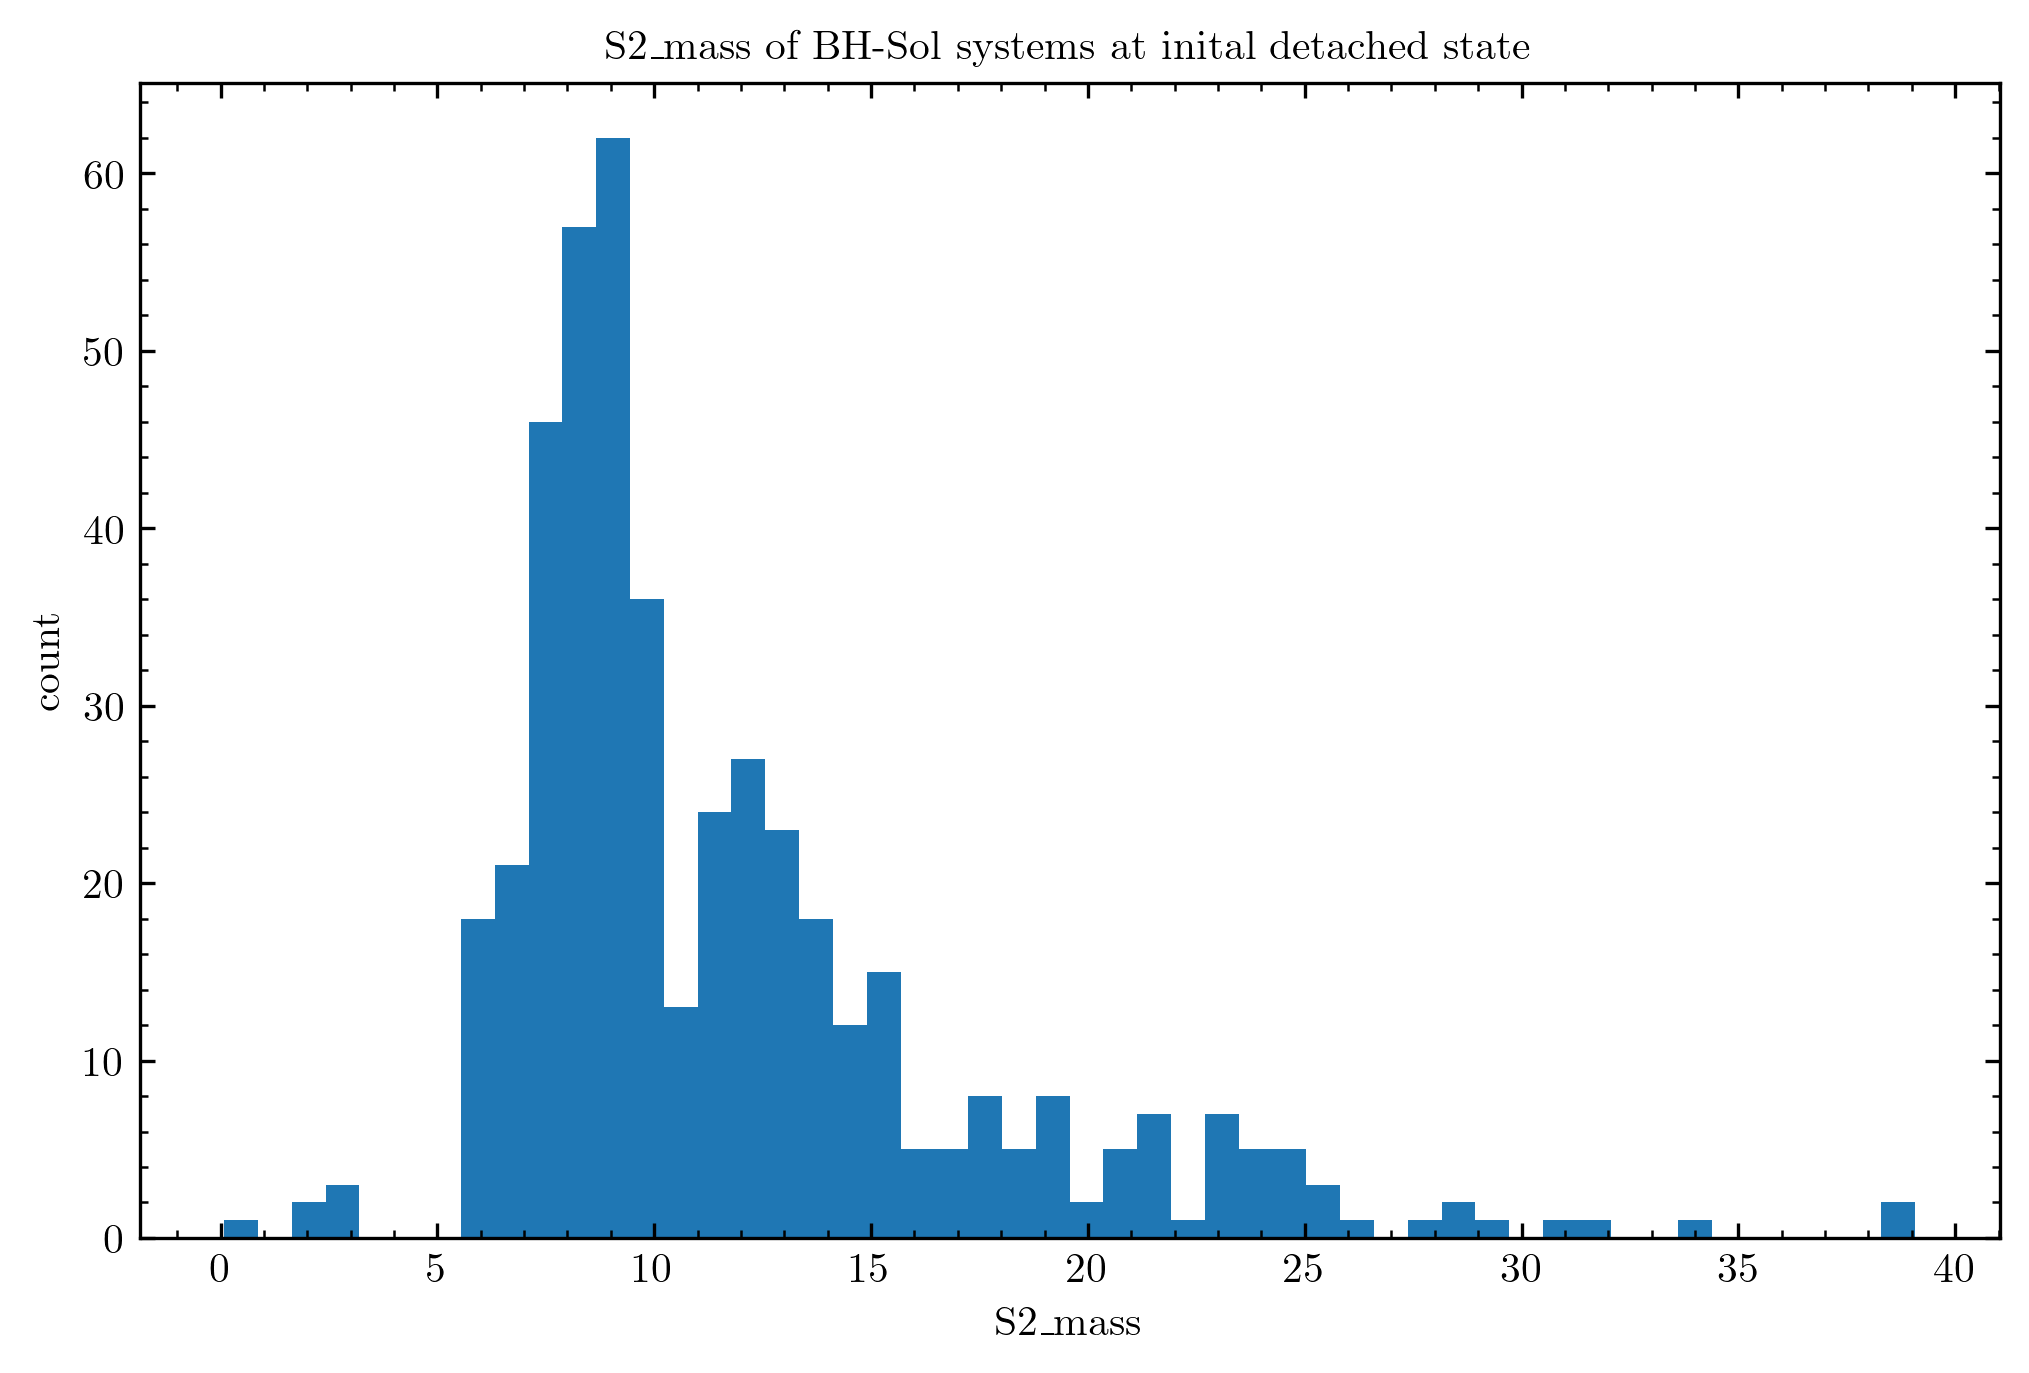

In [9]:
basicColHist(bhSolRows,'S2_mass')

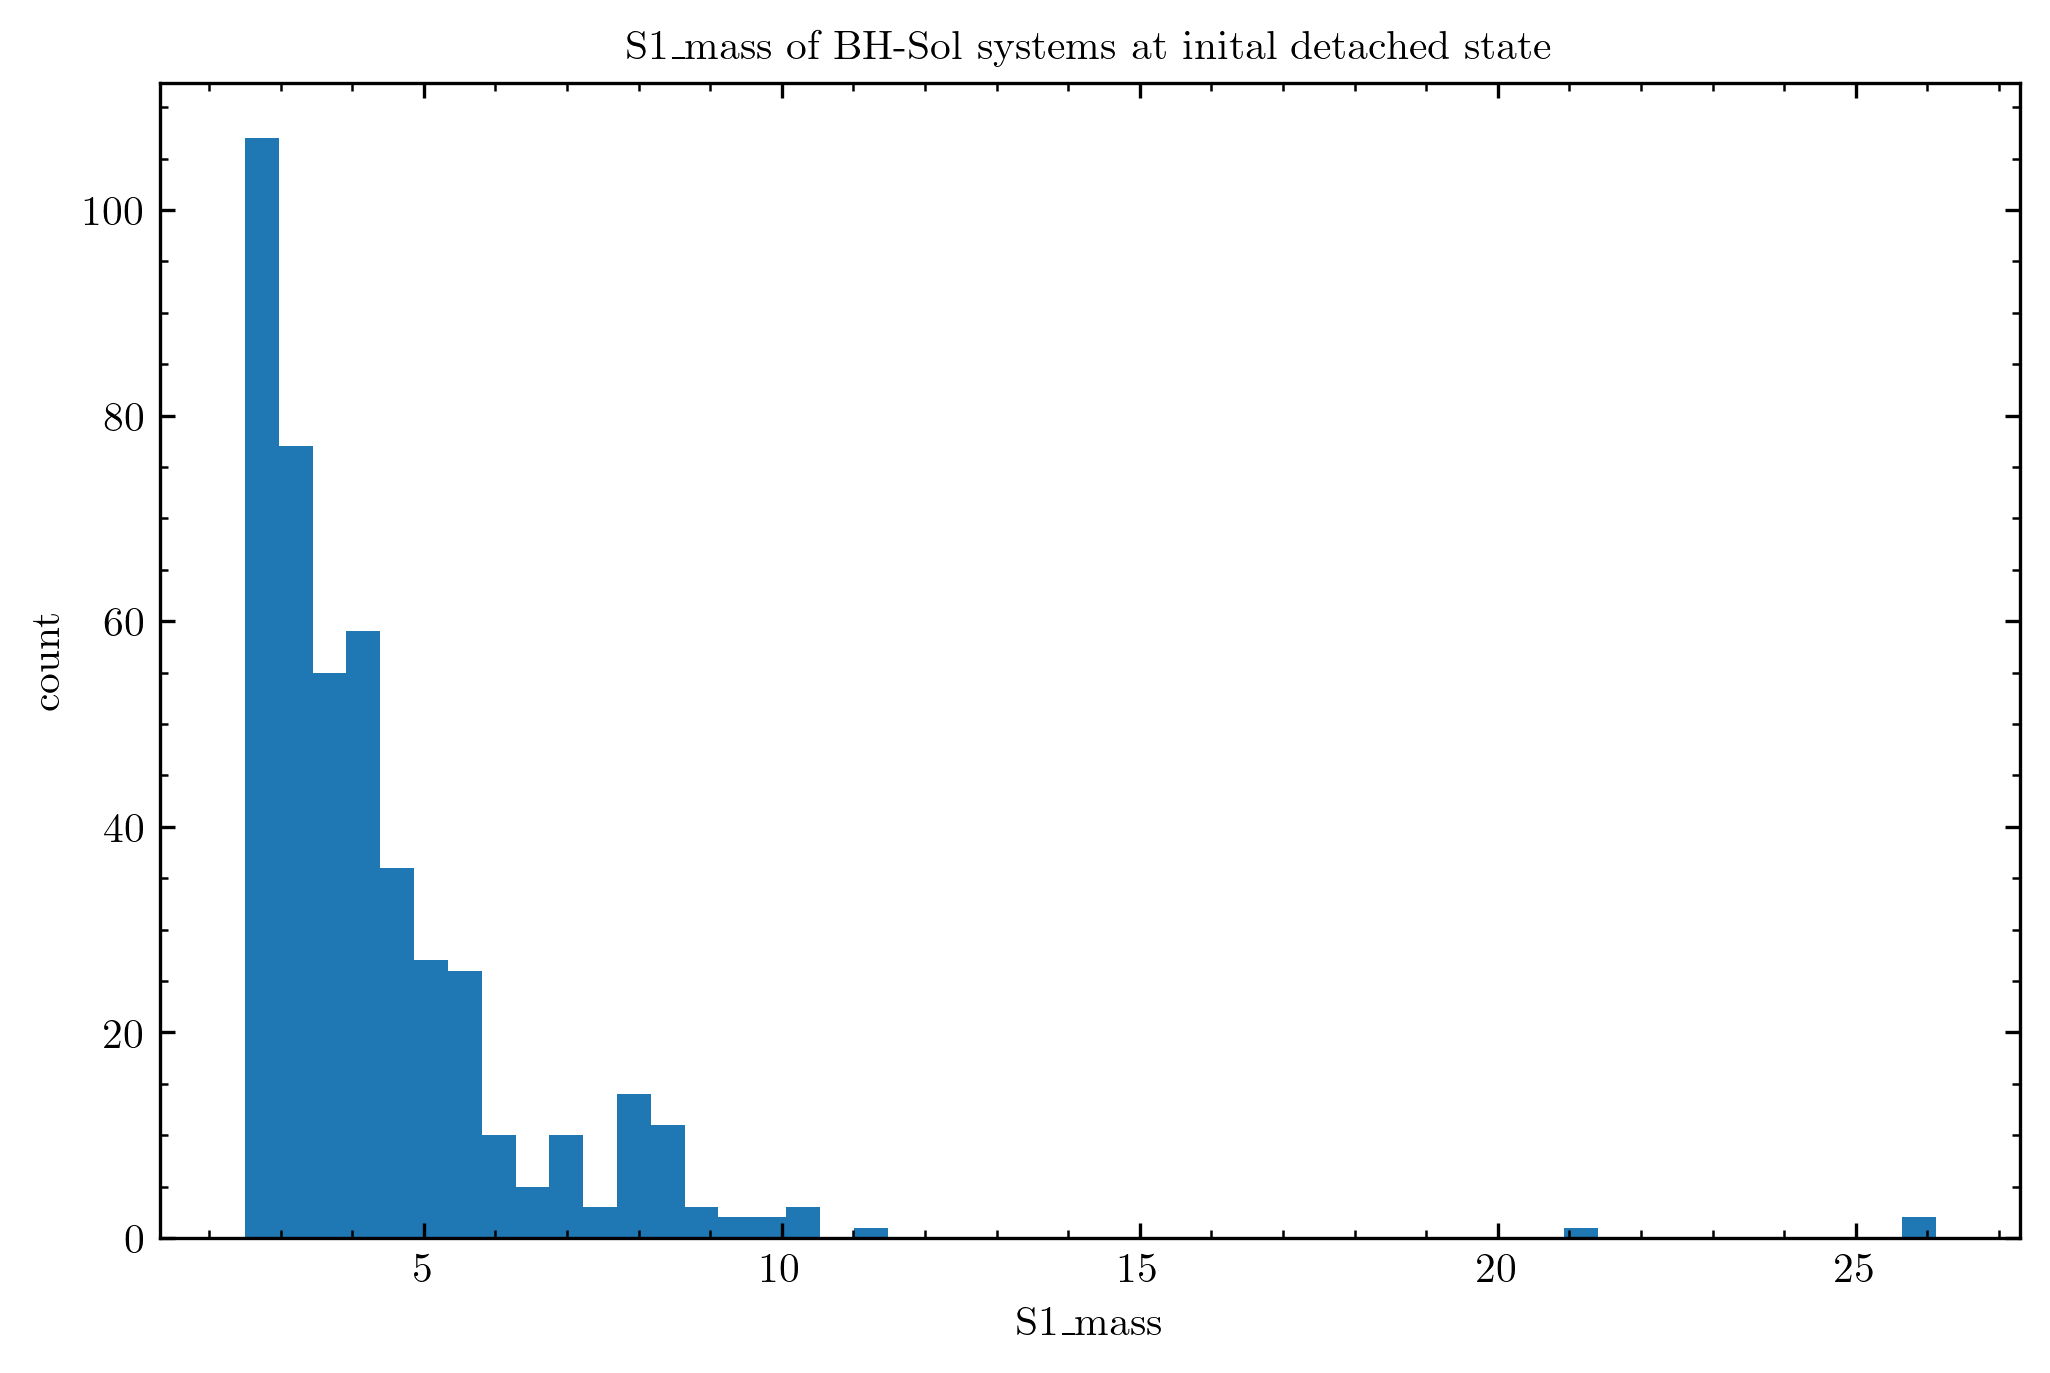

In [10]:
basicColHist(bhSolRows,'S1_mass')

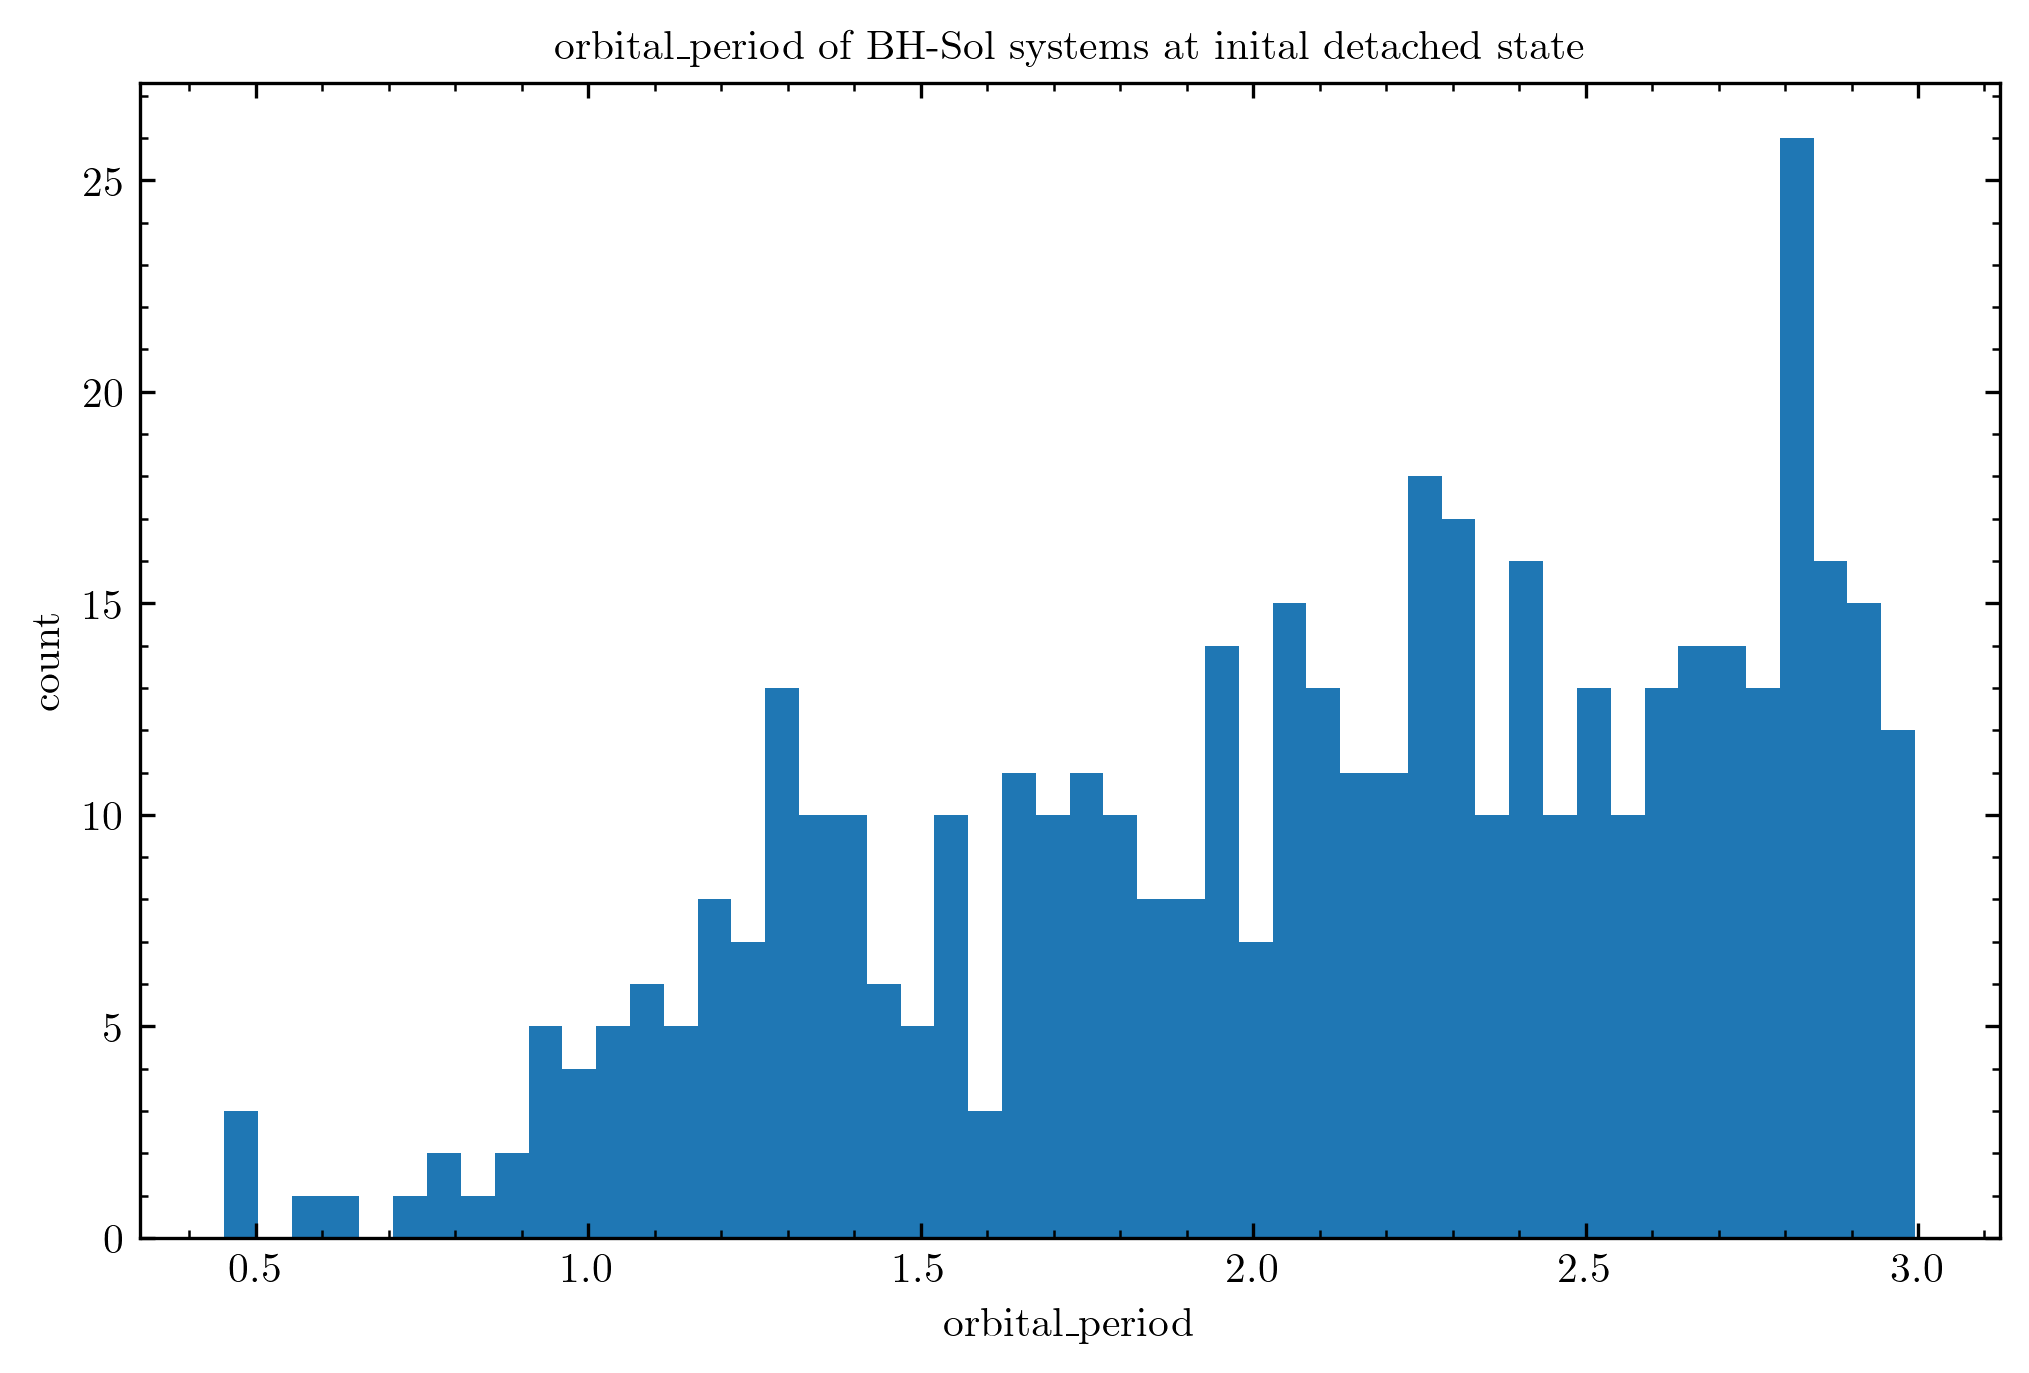

In [11]:
basicColHist(bhSolRows,'orbital_period', saveFig=True)


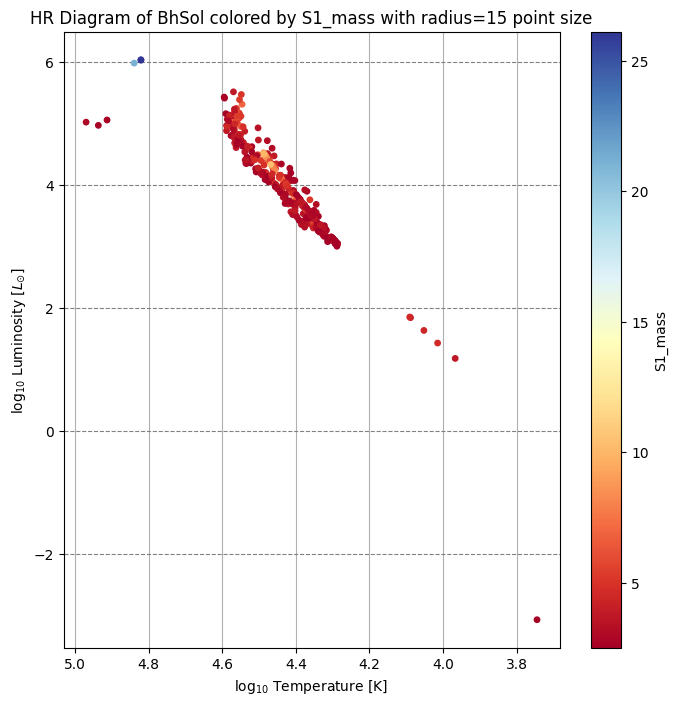

In [12]:
HR_Diagram(bhSolRows,
           'BhSol',
           Star_Radius=15)